# Overfitting

## 0. Imports

In [87]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.model_selection import StratifiedKFold

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [88]:
df = pd.read_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/dayofweek.csv')

In [89]:
display(df)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [90]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.2, random_state=21)
print("Class distribution without stratify:")
print("train:")
print(y_train_ns.value_counts(normalize=True).sort_index())
print("\ntest:")
print(y_test_ns.value_counts(normalize=True).sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y)

print("\nClass distribution with stratify:")
print("train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\ntest:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nDimensions:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Class distribution without stratify:
train:
dayofweek
0    0.077893
1    0.164688
2    0.092730
3    0.232196
4    0.059347
5    0.160237
6    0.212908
Name: proportion, dtype: float64

test:
dayofweek
0    0.091716
1    0.153846
2    0.071006
3    0.245562
4    0.071006
5    0.162722
6    0.204142
Name: proportion, dtype: float64

Class distribution with stratify:
train:
dayofweek
0    0.080861
1    0.162463
2    0.088279
3    0.234421
4    0.061573
5    0.160979
6    0.211424
Name: proportion, dtype: float64

test:
dayofweek
0    0.079882
1    0.162722
2    0.088757
3    0.236686
4    0.062130
5    0.159763
6    0.210059
Name: proportion, dtype: float64

Dimensions:
X_train: (1348, 43) X_test: (338, 43)


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [91]:
logreg = LogisticRegression(max_iter=1000, random_state=21, fit_intercept=False)
logreg.fit(X_train_ns, y_train_ns)
y_pred = logreg.predict(X_test_ns)
accuracy = accuracy_score(y_test_ns, y_pred)
print(f'Accuracy without stratification: {accuracy:.4f}')

logreg = LogisticRegression(max_iter=1000, random_state=21, fit_intercept=False)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with stratification: {accuracy:.4f}')

Accuracy without stratification: 0.6538
Accuracy with stratification: 0.6331


### b. SVM

In [92]:
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc.fit(X_train_ns, y_train_ns)
y_pred = svc.predict(X_test_ns)
accuracy = accuracy_score(y_test_ns, y_pred)
print(f'Accuracy without stratification: {accuracy:.4f}')

svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with stratification: {accuracy:.4f}')

Accuracy without stratification: 0.6331
Accuracy with stratification: 0.6183


### c. Decision tree

In [93]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X_train_ns, y_train_ns)
y_pred = dtc.predict(X_test_ns)
accuracy = accuracy_score(y_test_ns, y_pred)
print(f'Accuracy without stratification: {accuracy:.4f}')

dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with stratification: {accuracy:.4f}')

Accuracy without stratification: 0.5562
Accuracy with stratification: 0.5296


### d. Random forest

In [94]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rfc.fit(X_train_ns, y_train_ns)
y_pred = rfc.predict(X_test_ns)
accuracy = accuracy_score(y_test_ns, y_pred)
print(f'Accuracy without stratification: {accuracy:.4f}')

rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with stratification: {accuracy:.4f}')

Accuracy without stratification: 0.9467
Accuracy with stratification: 0.9290


All models showed similar metric values, with the exception of a slight decrease in accuracy for the Random forest model.

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [95]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

logreg = OneVsRestClassifier(LogisticRegression(solver='lbfgs', random_state=21, fit_intercept=False, max_iter=5000))
scores_lr = cross_val_score(logreg, X_train, y_train, cv=cv)
mean_accuracy_lr = np.mean(scores_lr)
std_deviation_lr = np.std(scores_lr)
print(f'Logistic Regression Mean Accuracy: {mean_accuracy_lr:.6f}, Std Deviation: {std_deviation_lr:.6f}')


Logistic Regression Mean Accuracy: 0.598706, Std Deviation: 0.028280


### b. SVM

In [96]:
svc = OneVsRestClassifier(SVC(kernel='linear', random_state=21, probability=False))
scores_svc = cross_val_score(svc, X_train, y_train, cv=cv)
mean_accuracy_svc = np.mean(scores_svc)
std_deviation_svc = np.std(scores_svc)
print(f'SVC Mean Accuracy: {mean_accuracy_svc:.6f}, Std Deviation: {std_deviation_svc:.6f}')


SVC Mean Accuracy: 0.570470, Std Deviation: 0.033579


### c. Decision tree

In [97]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
scores_dtc = cross_val_score(dtc, X_train, y_train, cv=cv)
mean_accuracy_dtc = np.mean(scores_dtc)
std_deviation_dtc = np.std(scores_dtc)
print(f'Decision Tree Mean Accuracy: {mean_accuracy_dtc:.6f}, Std Deviation: {std_deviation_dtc:.6f}')

Decision Tree Mean Accuracy: 0.507407, Std Deviation: 0.035428


### d. Random forest

In [98]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21, criterion="entropy", n_jobs=1)
scores_rfc = cross_val_score(rfc, X_train, y_train, cv=cv)
mean_accuracy_rfc = np.mean(scores_rfc)
std_deviation_rfc = np.std(scores_rfc)
print(f'Random Forest Mean Accuracy: {mean_accuracy_rfc:.6f}, Std Deviation: {std_deviation_rfc:.6f}')


Random Forest Mean Accuracy: 0.916915, Std Deviation: 0.027718


The best and final model is RandomForestClassifier?

## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [99]:
param_grid = {
    "n_estimators": [100],
    "max_depth": [25, None],
    "criterion": ["entropy"],
}

rfc = RandomForestClassifier(random_state=21)
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, scoring='accuracy', cv=10, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print('Optimal parameters:', best_params)
best_score = grid_search.best_score_
print('Best Cross-Validation Score:', best_score)

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END ..criterion=entropy, max_depth=25, n_estimators=100; total time=   0.4s
[CV] END criterion=entropy, max_depth=None, n_estimators=100; total time=   0.4s
[CV] END criterion=entropy, max_depth=None, n_es

In [100]:
final_model = RandomForestClassifier(**best_params, random_state=21)
final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, predictions)
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 0.9320


The best sign: numTrials with an importance coefficient: 0.2466


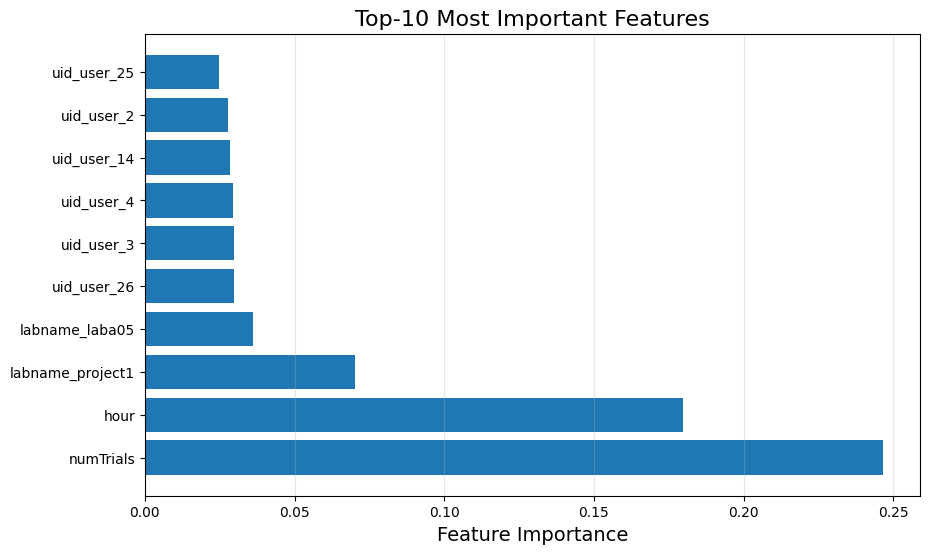

In [101]:
def plot_feature_importance(model, feature_names, n_top_features):
    importances = final_model.feature_importances_
    sorted_indices = np.argsort(importances)[::-1]
    top_n_indices = sorted_indices[:10]
    top_n_features = [feature_names[i] for i in top_n_indices]
    top_n_importances = importances[top_n_indices]


    print(f"The best sign: {top_n_features[0]} with an importance coefficient: {top_n_importances[0]:.4f}")
    

    plt.figure(figsize=(10, 6))
    plt.barh(top_n_features, top_n_importances)
    plt.xlabel('Feature Importance', fontsize=14)
    plt.ylabel('')
    plt.title('Top-10 Most Important Features', fontsize=16)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()
feature_names = list(X.columns)
plot_feature_importance(final_model, feature_names, 10)

In [102]:
joblib.dump(final_model, 'random_forest_model.joblib')

['random_forest_model.joblib']

In [103]:
loaded_model = joblib.load('random_forest_model.joblib')
predictions_loaded = loaded_model.predict(X_test)
test_accuracy_loaded = accuracy_score(y_test, predictions_loaded)
print(f'Test Accuracy after loading the model: {test_accuracy_loaded:.4f}')

Test Accuracy after loading the model: 0.9320
